# Event Classification Evaluation

This notebook will evaluate our model on the **test** set.

In [1]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
import sys
sys.path.append('..')
from src.data_utils import load_datasets_hdf5
from src.model_utils.model import build_classifier

# Set matplotlib style
plt.style.use('hep.mplstyle')

## Load Model and Test Data

In [2]:
# Set paths
model_path = "../run/best_model.keras"
data_file = "../datasets/processed_data_20250411-011241.h5"
batch_size = 4000

In [3]:
# Build a fresh model and load weights
print(f"Building fresh model and loading weights from {model_path}")

# Enable unsafe deserialization
model = build_classifier()
tf.keras.config.enable_unsafe_deserialization()

# Load weights
model.load_weights(model_path)

Building fresh model and loading weights from ../run/best_model.keras


In [4]:
# Load test data
print(f"Loading data from {data_file}")
data = load_datasets_hdf5(data_file, batch_size=batch_size)
train_data = data['train']
test_data = data['test']

# Create TF dataset for prediction
train_ds = tf.data.Dataset.from_tensor_slices((
    {
        "global_input": train_data['global'],
        "particle_input": train_data['particle'],
        "particle_mask": train_data['particle_mask'],
        "sv_input": train_data['sv'],
        "sv_mask": train_data['sv_mask']
    },
    train_data['labels']
)).batch(batch_size)

test_ds = tf.data.Dataset.from_tensor_slices((
    {
        "global_input": test_data['global'],
        "particle_input": test_data['particle'],
        "particle_mask": test_data['particle_mask'],
        "sv_input": test_data['sv'],
        "sv_mask": test_data['sv_mask']
    },
    test_data['labels']
)).batch(batch_size)

Loading data from ../datasets/processed_data_20250411-011241.h5


In [5]:
# Takes 3 mins to run (on my MacBook)
y_train_true = tf.concat([y for _, y in train_ds], axis=0).numpy()
y_train_pred_proba = model.predict(train_ds, verbose=0)

y_test_true = tf.concat([y for _, y in test_ds], axis=0).numpy()
y_test_pred_proba = model.predict(test_ds, verbose=0)

y_train_pred = np.argmax(y_train_pred_proba, axis=1)
y_test_pred = np.argmax(y_test_pred_proba, axis=1)

# Class labels
class_names = ["b-event", "c-event", "s-event"]

2025-04-28 15:04:21.387701: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-04-28 15:06:19.317869: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## Visualise Classifier Outputs for Each Class

In [6]:
# Prepare data for visualisation
df_train_results = pd.DataFrame()
df_test_results = pd.DataFrame()

# Add true class
df_train_results['true_class'] = [class_names[int(i)] for i in y_train_true]
df_test_results['true_class'] = [class_names[int(i)] for i in y_test_true]

# Add probabilities
for i, class_name in enumerate(class_names):
    df_train_results[f'{class_name}_prob'] = y_train_pred_proba[:, i]
    df_test_results[f'{class_name}_prob'] = y_test_pred_proba[:, i]
    
# Display first few rows
df_train_results.head()

,true_class,b-event_prob,c-event_prob,s-event_prob
0,c-event,4.094172e-03,9.955831e-01,0.000323
1,s-event,4.640762e-16,9.176164e-04,0.999082
2,s-event,3.768331e-29,1.752674e-06,0.999998
3,s-event,0.000000e+00,1.587137e-10,1.000000
4,b-event,6.504308e-01,3.231159e-01,0.026453


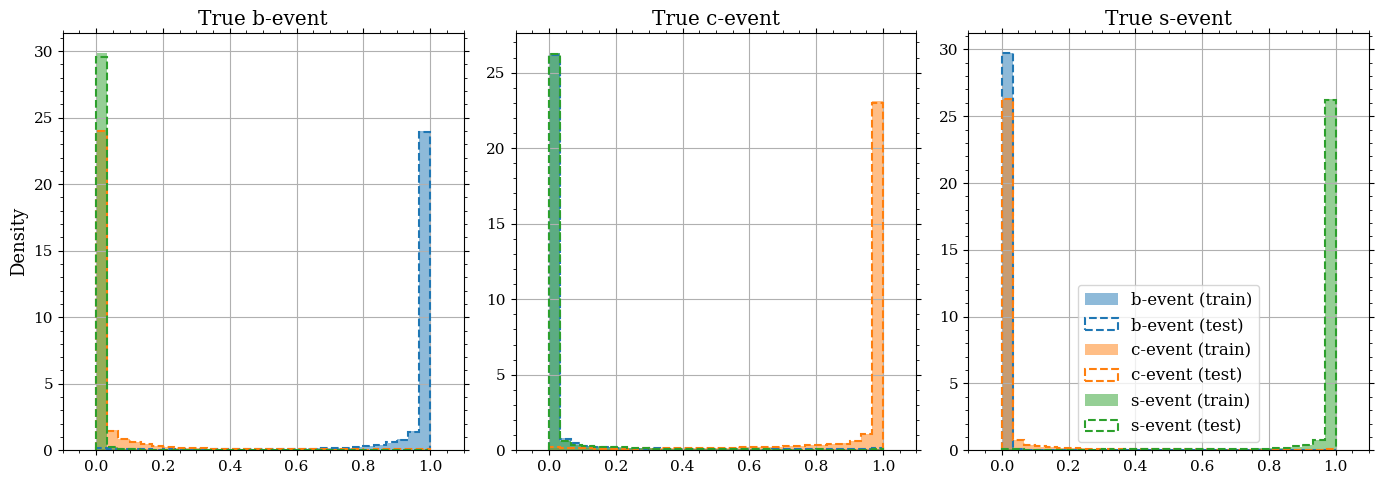

In [7]:
colormap = plt.get_cmap('tab10')

fig, axes = plt.subplots(1, len(class_names), figsize=(14, 5))

for i, true_class in enumerate(class_names):
    class_mask_train = y_train_true == i
    class_mask_test = y_test_true == i

    for j, pred_class in enumerate(class_names):
        colour = colormap(j)

        axes[i].hist(
            y_train_pred_proba[class_mask_train, j],
            bins=30,
            alpha=0.5,
            color=colour,
            density=True,
            label=f'{pred_class} (train)'
        )

        axes[i].hist(
            y_test_pred_proba[class_mask_test, j],
            bins=30,
            histtype='step',
            density=True,
            color=colour,
            linewidth=1.5,
            linestyle='dashed',
            label=f'{pred_class} (test)'
        )

    axes[i].set_xlim(-0.1, 1.1)
    axes[i].set_title(f'True {true_class}')
    axes[i].grid(True)

axes[0].set_ylabel('Density')
axes[2].legend()
plt.tight_layout()
plt.savefig('figures/prob_histograms.pdf')
plt.show()

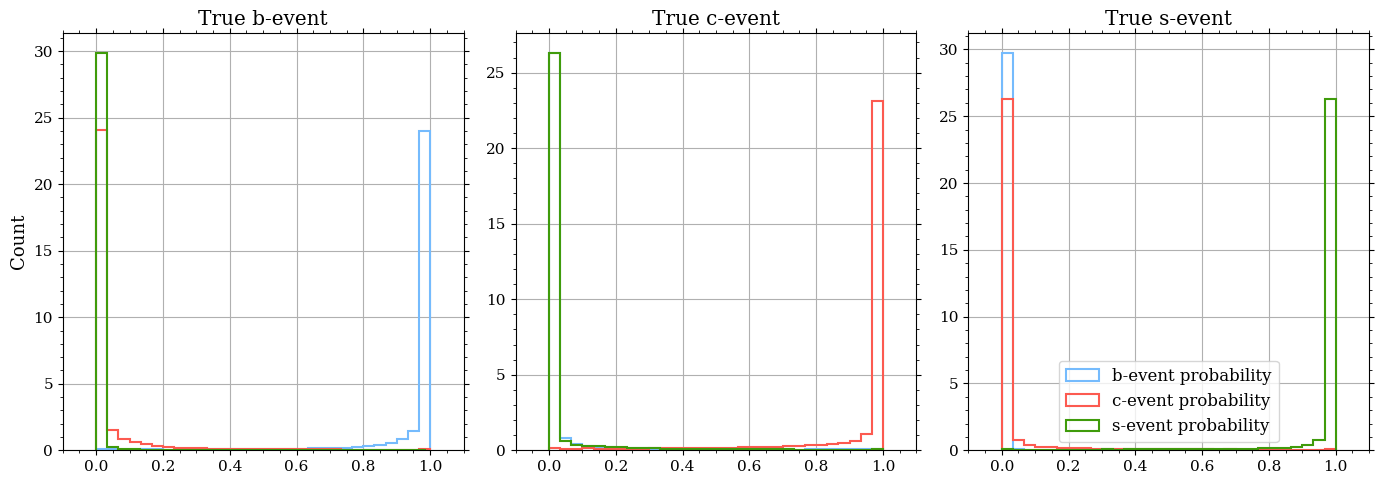

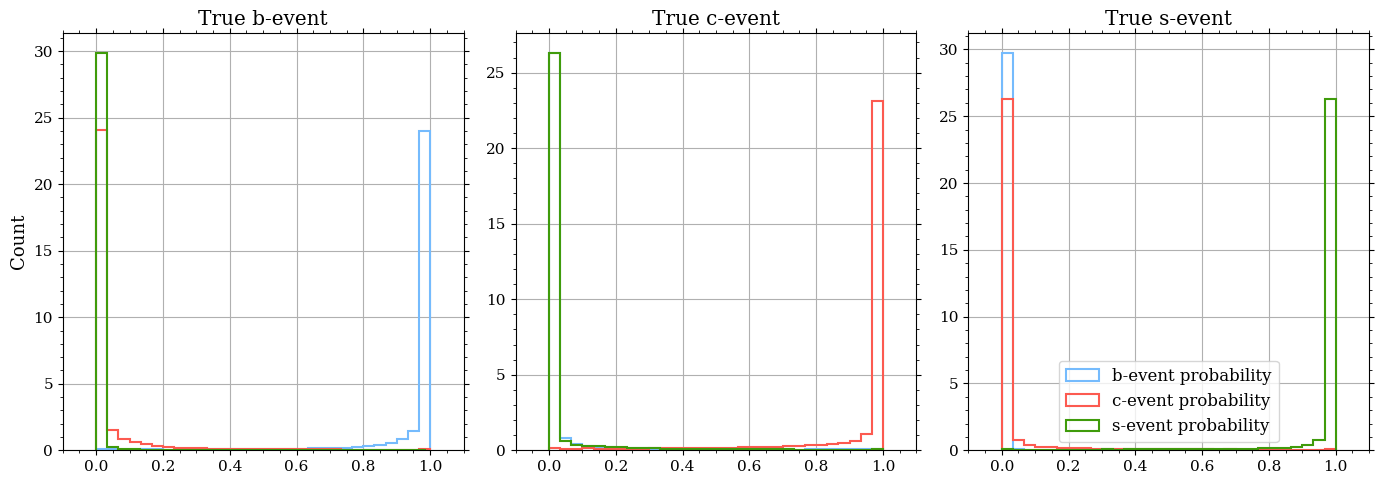

In [8]:
# Create histograms of the probabilities
fig, axes = plt.subplots(1, len(class_names), figsize=(14, 5))

for i, true_class in enumerate(class_names):
    # Filter data for this true class
    class_mask = y_train_true == i
    
    # Plot histograms for each probability
    for j, pred_class in enumerate(class_names):
        axes[i].hist(
            y_train_pred_proba[class_mask, j],
            bins=30,
            histtype='step',
            density=True,
            linewidth=1.5,
            label=f'{pred_class} probability'
        )

    axes[i].set_xlim(-0.1, 1.1)
    axes[i].set_title(f'True {true_class}')
    axes[i].grid(True)
axes[0].set_ylabel('Count')
axes[2].legend()

plt.tight_layout()
plt.show()

# Create histograms of the probabilities
fig, axes = plt.subplots(1, len(class_names), figsize=(14, 5))

for i, true_class in enumerate(class_names):
    # Filter data for this true class
    class_mask = y_train_true == i
    
    # Plot histograms for each probability
    for j, pred_class in enumerate(class_names):
        axes[i].hist(
            y_train_pred_proba[class_mask, j],
            bins=30,
            histtype='step',
            density=True,
            linewidth=1.5,
            label=f'{pred_class} probability'
        )

    axes[i].set_xlim(-0.1, 1.1)
    axes[i].set_title(f'True {true_class}')
    axes[i].grid(True)
axes[0].set_ylabel('Count')
axes[2].legend()

plt.tight_layout()
plt.show()

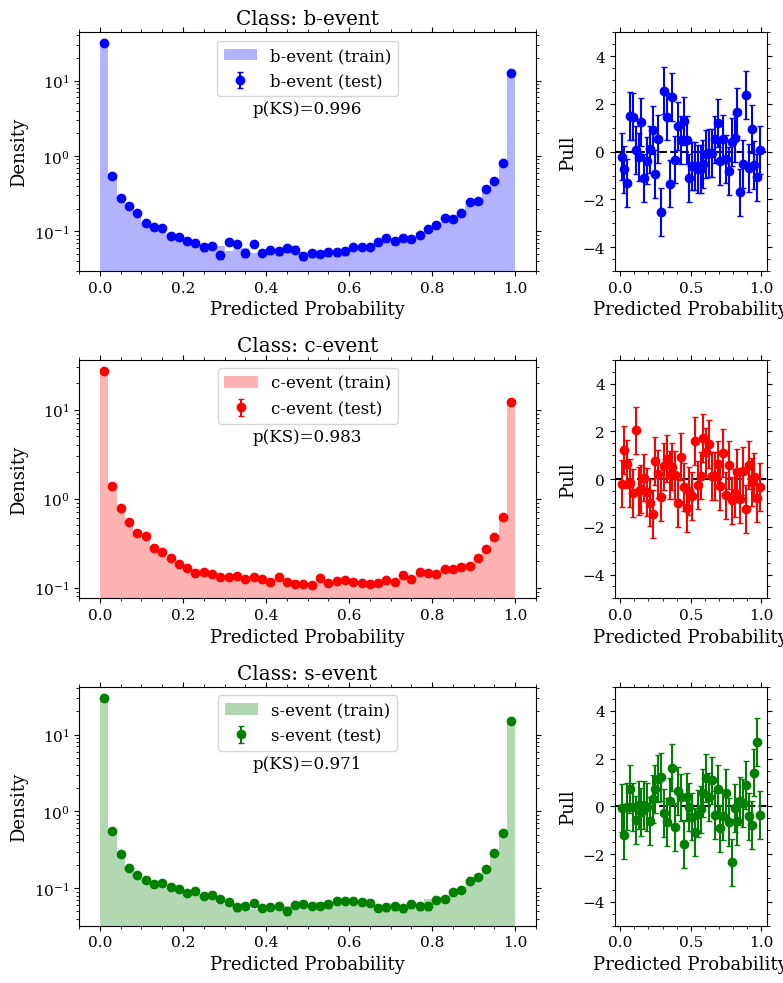

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kstest
import pandas as pd

# Assuming df_train_results and df_test_results are already created as shown in your input
class_names = ["b-event", "c-event", "s-event"]
# Define colors for each class
class_colors = {
    "b-event": "blue",
    "c-event": "red",
    "s-event": "green"
}

# Prepare figure with 3 rows (one for each class) and 2 subplots (hist and pull)
fig, axes = plt.subplots(3, 2, figsize=(8, 10), 
                        gridspec_kw={'height_ratios': [3, 3, 3], 'width_ratios': [3, 1]})

for idx, class_name in enumerate(class_names):
    # Get color for the current class
    color = class_colors[class_name]
    
    # Extract probabilities for the current class
    train_prob = df_train_results[f'{class_name}_prob'].values
    test_prob = df_test_results[f'{class_name}_prob'].values
    
    # Filter probabilities by true class (optional: here we use all samples)
    train_pred_class = train_prob
    test_pred_class = test_prob
    
    # Perform KS test to compare train and test distributions
    ks_stat, ks_pvalue = kstest(train_pred_class, test_pred_class)
    
    # Histogram for training data
    axes[idx, 0].hist(train_pred_class, bins=50, range=(0, 1), alpha=0.3, density=True,
                      label=f'{class_name} (train)', color=color)
    
    # Histogram for test data
    nh_test, xe = np.histogram(test_pred_class, bins=50, range=(0, 1))
    dh_test, xe = np.histogram(test_pred_class, bins=50, range=(0, 1), density=True)
    de_test = dh_test * (nh_test**0.5 / nh_test)  # Error estimation
    cx = 0.5 * (xe[1:] + xe[:-1])  # Bin centers
    
    # Plot test data with error bars (using same color)
    axes[idx, 0].errorbar(cx, dh_test, de_test, fmt='o', color=color, 
                         label=f'{class_name} (test)')
    
    # Histogram for training data (for pull calculation)
    nh_train, xe = np.histogram(train_pred_class, bins=50, range=(0, 1))
    dh_train, xe = np.histogram(train_pred_class, bins=50, range=(0, 1), density=True)
    de_train = dh_train * (nh_train**0.5 / nh_train)
    
    # Calculate pull: (test - train) / sqrt(error_train^2 + error_test^2)
    diff = dh_test - dh_train
    error = np.sqrt(de_train**2 + de_test**2)
    pull = diff / error
    pull_error = np.ones_like(pull)  # Standard error for pull
    
    # Pull plot
    axes[idx, 1].axhline(0, c='k', ls='--')
    axes[idx, 1].errorbar(cx, pull, pull_error, fmt='o', color=color)
    
    # Add KS p-value to histogram plot
    axes[idx, 0].text(0.5, 0.66, f'p(KS)={ks_pvalue:.3f}', 
                      transform=axes[idx, 0].transAxes, ha='center')
    
    # Customize histogram plot
    axes[idx, 0].set_title(f'Class: {class_name}')
    axes[idx, 0].set_xlabel('Predicted Probability')
    axes[idx, 0].set_ylabel('Density')
    axes[idx, 0].set_yscale('log')
    axes[idx, 0].legend(loc='upper center')
    
    # Customize pull plot
    axes[idx, 1].set_xlabel('Predicted Probability')
    axes[idx, 1].set_ylabel('Pull')
    axes[idx, 1].set_ylim(-5, 5)  # Adjust as needed

# Adjust layout
plt.tight_layout()
plt.savefig('figures/prob_pull_histograms.pdf')
plt.show()

## Confusion Matrix and Classification Report

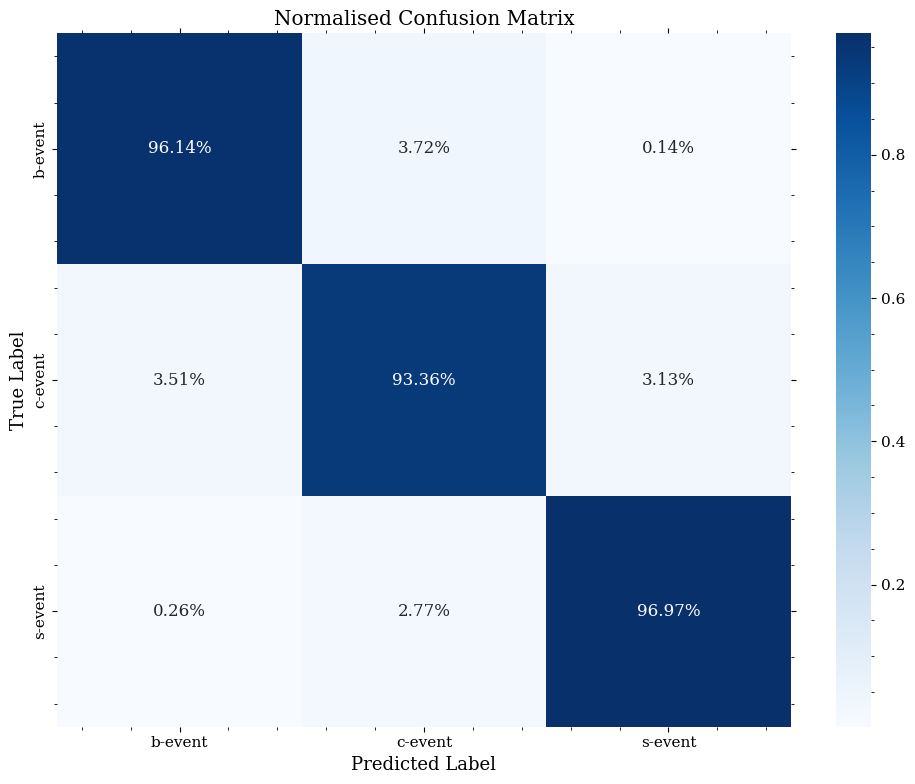

In [10]:
# Calculate confusion matrix
cm = confusion_matrix(y_test_true, y_test_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Plot normalized confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_norm, annot=True, fmt='.2%', cmap='Blues',
    xticklabels=class_names, yticklabels=class_names
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Normalised Confusion Matrix')
plt.tight_layout()
plt.savefig('figures/confusion_matrix.pdf')
plt.show()

In [11]:
# Classification report
report = classification_report(y_test_true, y_test_pred, target_names=class_names, digits=3)
print(report)

              precision    recall  f1-score   support

     b-event      0.962     0.961     0.962     29710
     c-event      0.934     0.934     0.934     29968
     s-event      0.969     0.970     0.969     31854

    accuracy                          0.955     91532
   macro avg      0.955     0.955     0.955     91532
weighted avg      0.955     0.955     0.955     91532



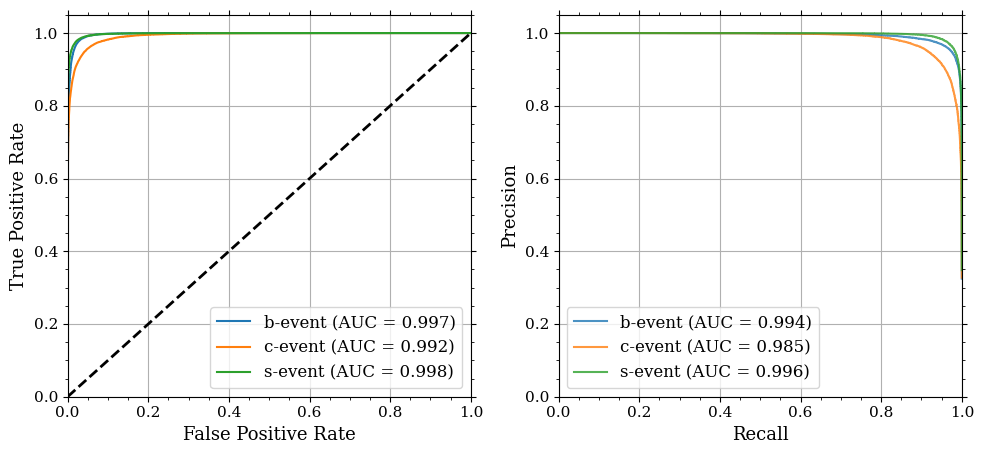

In [12]:
# One-hot encode true class labels
y_true_onehot = pd.get_dummies(df_test_results['true_class'])

# Create subplots
fig, axs = plt.subplots(1, 2, figsize=(10, 4.7))

colormap = plt.get_cmap('tab10')

# ROC Curve
for i, class_name in enumerate(class_names):
    y_true_class = y_true_onehot[class_name].values
    y_pred_class = df_test_results[f'{class_name}_prob'].values
    
    if len(y_true_class) > 0 and len(y_pred_class) > 0:
        fpr, tpr, _ = roc_curve(y_true_class, y_pred_class)
        roc_auc = auc(fpr, tpr)
        colour = colormap(i)
        axs[0].plot(fpr, tpr, lw=1.5, label=f'{class_name} (AUC = {roc_auc:.3f})', color=colour)


axs[0].plot([0, 1], [0, 1], 'k--', lw=2)
axs[0].set_xlim([0.0, 1.0])
axs[0].set_ylim([0.0, 1.05])
axs[0].set_xlabel('False Positive Rate')
axs[0].set_ylabel('True Positive Rate')
# axs[0].set_title('Receiver Operating Characteristic')
axs[0].legend(loc='lower right')
axs[0].grid(True)

# PR Curve
for i, class_name in enumerate(class_names):
    y_true_class = y_true_onehot[class_name].values
    y_pred_class = df_test_results[f'{class_name}_prob'].values
    
    if len(y_true_class) > 0 and len(y_pred_class) > 0:
        precision, recall, _ = precision_recall_curve(y_true_class, y_pred_class)
        pr_auc = auc(recall, precision)
        colour = colormap(i)
        axs[1].plot(recall, precision, lw=1.5, alpha=0.8, label=f'{class_name} (AUC = {pr_auc:.3f})', color=colour)

axs[1].set_xlim([0.0, 1.0])
axs[1].set_ylim([0.0, 1.05])
axs[1].set_xlabel('Recall')
axs[1].set_ylabel('Precision')
# axs[1].set_title('Precision-Recall Curve')
axs[1].legend(loc='lower left')
axs[1].grid(True)

plt.tight_layout()
plt.savefig('figures/roc_pr_curves.pdf')
plt.show()

### Plot Sample Predictions

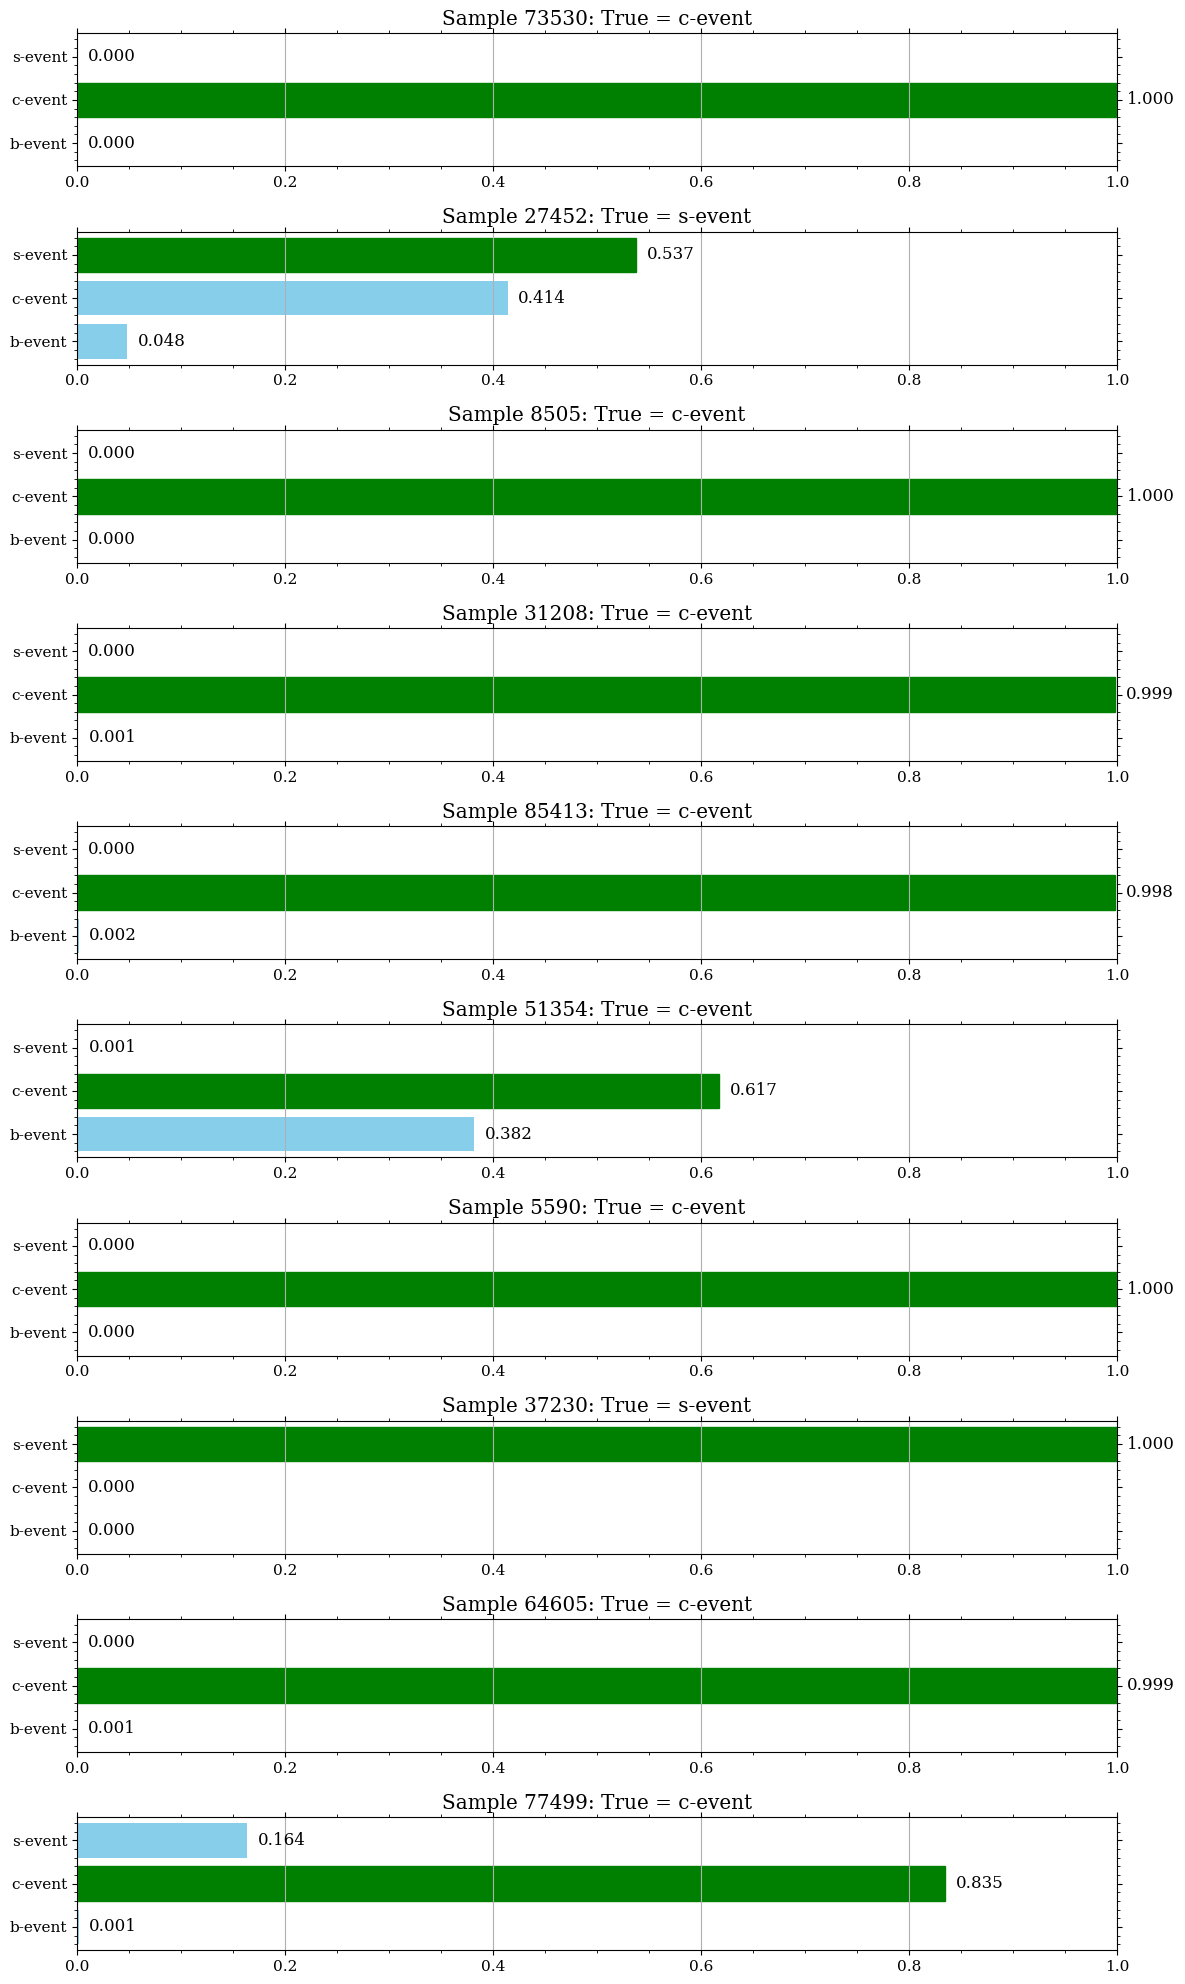

In [13]:
# Sample random indices
num_samples = 10
indices = np.random.choice(len(df_test_results), min(num_samples, len(df_test_results)), replace=False)

# Create a figure
fig, axes = plt.subplots(len(indices), 1, figsize=(12, 2*len(indices)))

if len(indices) == 1:
    axes = [axes]

for i, idx in enumerate(indices):
    row = df_test_results.iloc[idx]
    true_class = row['true_class']
    
    # Get probabilities
    probs = [row[f'{class_name}_prob'] for class_name in class_names]
    
    # Create horizontal bar chart
    bars = axes[i].barh(class_names, probs, color='skyblue')
    
    # Highlight the true label
    true_idx = class_names.index(true_class)
    bars[true_idx].set_color('green')
    
    # Highlight predicted label if different from true
    pred_idx = np.argmax(probs)
    if pred_idx != true_idx:
        bars[pred_idx].set_color('red')
    
    # Add probabilities as text
    for j, bar in enumerate(bars):
        width = bar.get_width()
        axes[i].text(
            width + 0.01, bar.get_y() + bar.get_height()/2,
            f'{probs[j]:.3f}', ha='left', va='center'
        )
    
    axes[i].set_xlim(0, 1)
    axes[i].set_title(f'Sample {idx}: True = {true_class}')
    axes[i].grid(True, axis='x')

plt.tight_layout()
plt.show()

## Visualise Training Curves

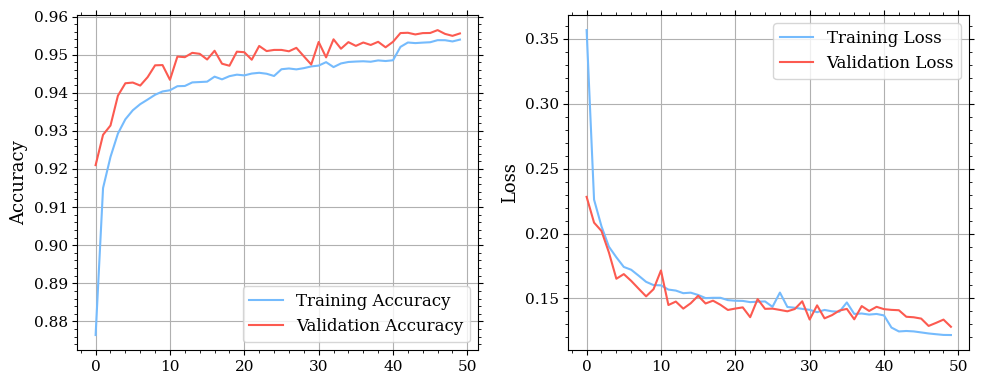

In [14]:
import matplotlib.pyplot as plt
import json

data = json.load(open('../run/training_history.json'))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Subplot 1: Accuracy
axes[0].plot(data["sparse_categorical_accuracy"], label='Training Accuracy')
axes[0].plot(data["val_sparse_categorical_accuracy"], label='Validation Accuracy')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Subplot 2: Loss
axes[1].plot(data["loss"], label='Training Loss')
axes[1].plot(data["val_loss"], label='Validation Loss')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('figures/training_curves.pdf')
plt.show()